# Brzina i Pritisak CSV Plotovi

```powershell
SDL_VIDEODRIVER=x11 python src/pygame_viewer_venturi.py --geometry venturi --frames 600 --viscosity 0 --damping 100 --export-csv exports/venturi.csv
SDL_VIDEODRIVER=x11 python src/pygame_viewer_venturi.py --geometry flat --frames 600 --export-csv exports/flat.csv
```

In [17]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CSV_FILES = sorted((PROJECT_ROOT / "exports").glob("*.csv"))
CSV_FILES

[PosixPath('/home/pfe/lk-s-2026-simulacija-fluida/exports/flat.csv'),
 PosixPath('/home/pfe/lk-s-2026-simulacija-fluida/exports/venturi.csv')]

In [18]:
frames = []
for path in CSV_FILES:
    df = pd.read_csv(path)
    df["source"] = path.stem
    frames.append(df)

if not frames:
    raise FileNotFoundError("No CSV files found. Export data into the exports folder or update CSV_FILES.")

data = pd.concat(frames, ignore_index=True)
data = data[data["frame"] > 1]
data.head()

,frame,geometry,preset,time,p_wide,p_narrow,p_delta,speed_wide,speed_narrow,speed_ratio,...,v3,v3_v1,divergence,vorticity,curl,kinetic_energy,cfl,l2_div,avg_l2_div,source
1,2,flat,four_vortices,0.02,18.776049,-16.763544,35.539594,9.829936,9.829901,0.999996,...,9.866028,0.997060,819.675744,70353.194272,121.305763,1.605072e+06,2.270008,97.428243,96.276230,flat
2,3,flat,four_vortices,0.03,11.573196,-10.925373,22.498568,9.831113,9.831350,1.000024,...,9.881377,0.997488,548.370880,66938.410350,105.637528,1.602562e+06,2.012842,98.227711,96.926723,flat
3,4,flat,four_vortices,0.04,9.410785,-8.800556,18.211341,9.832073,9.832881,1.000082,...,9.894774,0.997857,399.976689,64775.286905,102.757407,1.601245e+06,1.822941,98.664198,97.361092,flat
4,5,flat,four_vortices,0.05,8.402801,-7.877734,16.280535,9.832874,9.834871,1.000203,...,9.907045,0.998192,306.469116,63273.312231,102.585486,1.600638e+06,1.687855,98.955852,97.680044,flat
5,6,flat,four_vortices,0.06,7.651805,-7.213277,14.865082,9.833551,9.836500,1.000300,...,9.918449,0.998504,243.442462,62153.273769,102.471933,1.600444e+06,1.590462,99.165262,97.927580,flat


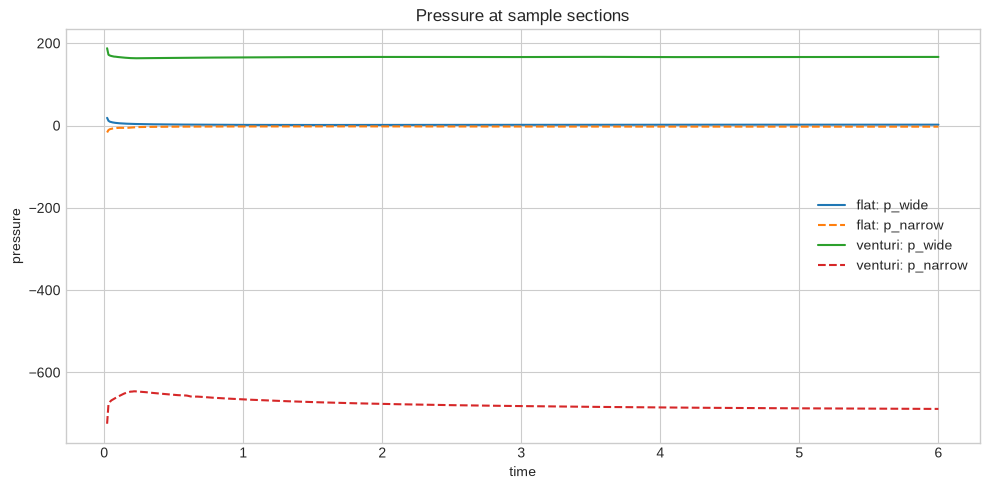

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
for label, group in data.groupby("source"):
    ax.plot(group["time"], group["p_wide"], label=f"{label}: p_wide")
    ax.plot(group["time"], group["p_narrow"], linestyle="--", label=f"{label}: p_narrow")

ax.set_title("Pressure at sample sections")
ax.set_xlabel("time")
ax.set_ylabel("pressure")
ax.legend()
fig.tight_layout()

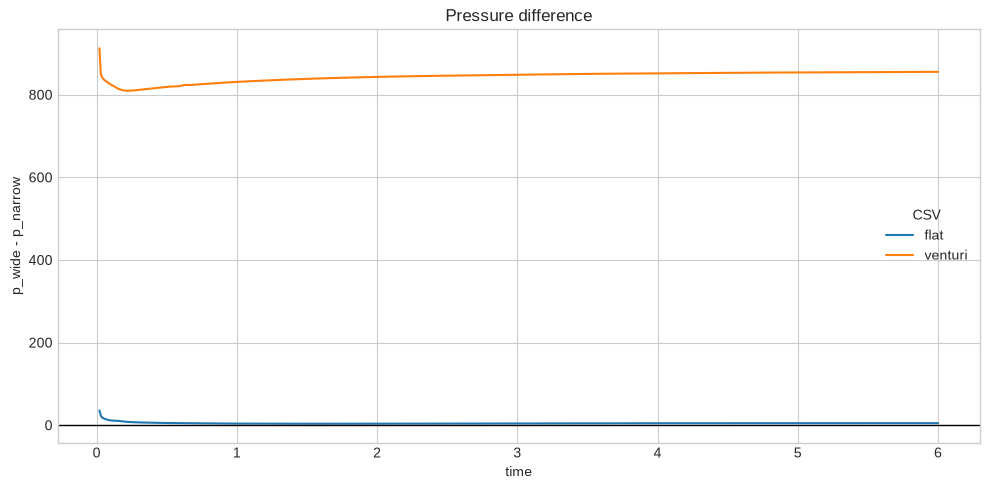

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
for label, group in data.groupby("source"):
    ax.plot(group["time"], group["p_delta"], label=label)

ax.axhline(0, color="black", linewidth=1)
ax.set_title("Pressure difference")
ax.set_xlabel("time")
ax.set_ylabel("p_wide - p_narrow")
ax.legend(title="CSV")
fig.tight_layout()

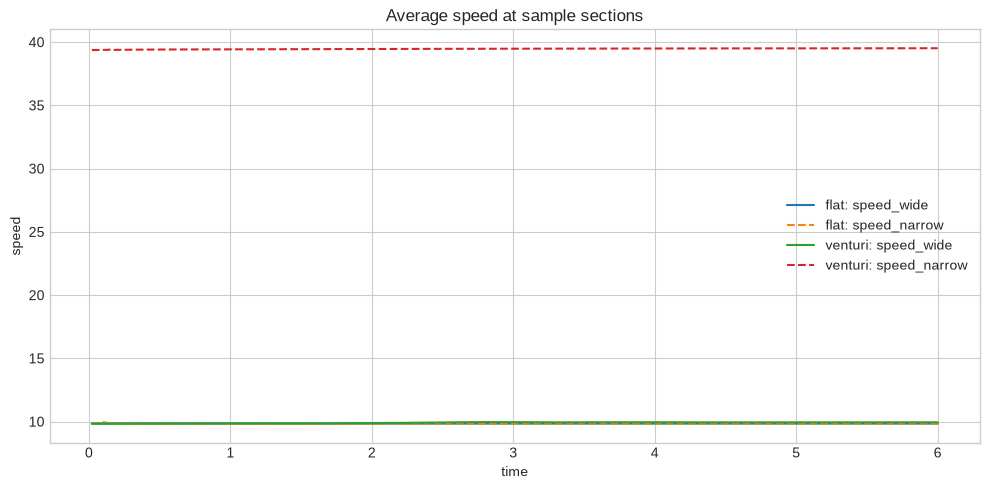

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
for label, group in data.groupby("source"):
    ax.plot(group["time"], group["speed_wide"], label=f"{label}: speed_wide")
    ax.plot(group["time"], group["speed_narrow"], linestyle="--", label=f"{label}: speed_narrow")

ax.set_title("Average speed at sample sections")
ax.set_xlabel("time")
ax.set_ylabel("speed")
ax.legend()
fig.tight_layout()

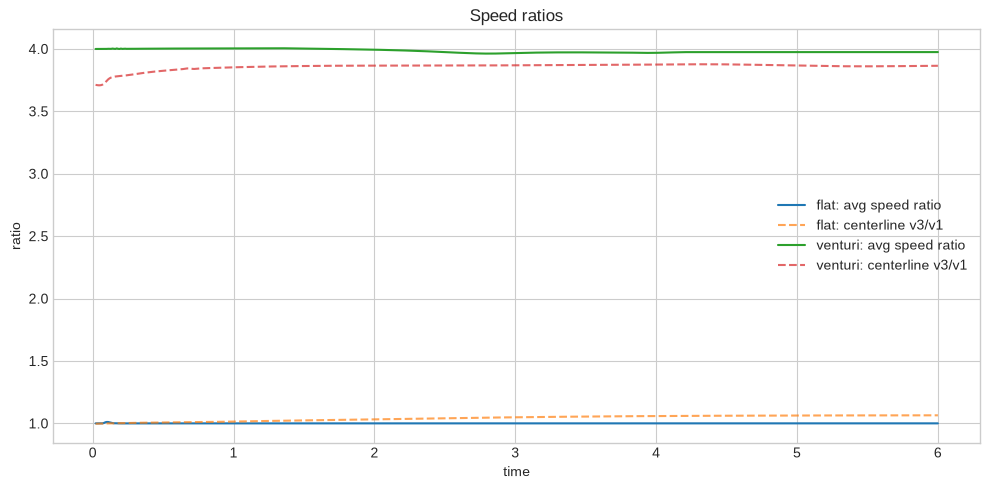

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
for label, group in data.groupby("source"):
    ax.plot(group["time"], group["speed_ratio"], label=f"{label}: avg speed ratio")
    ax.plot(group["time"], group["v3_v1"], linestyle="--", alpha=0.7, label=f"{label}: centerline v3/v1")

ax.set_title("Speed ratios")
ax.set_xlabel("time")
ax.set_ylabel("ratio")
ax.legend()
fig.tight_layout()